# Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load Dataset

In [3]:
data = pd.read_csv('/content/non_overfitting_student_behavior_dataset.csv')
# Display first 5 rows
data.head()

,tab_switches,typing_speed,idle_time,mouse_movements,copy_paste_count,suspicious
0,0,48,43,30,0,1
1,5,38,74,153,9,1
2,2,40,15,97,1,1
3,6,23,39,128,5,0
4,1,36,38,98,3,1


# Data Preprocessing

In [4]:
# To Check Datatype
print(data.info())
# To Check 5 Points summary data
print(data.describe())
# To Check Null Values
print(data.isnull().sum())
# To Check Duplicate values
print(data.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   tab_switches      1500 non-null   int64
 1   typing_speed      1500 non-null   int64
 2   idle_time         1500 non-null   int64
 3   mouse_movements   1500 non-null   int64
 4   copy_paste_count  1500 non-null   int64
 5   suspicious        1500 non-null   int64
dtypes: int64(6)
memory usage: 70.4 KB
None
       tab_switches  typing_speed    idle_time  mouse_movements  \
count   1500.000000   1500.000000  1500.000000      1500.000000   
mean       3.896000     39.078667    35.026000        99.226667   
std        2.407152     10.178681    16.363858        38.828483   
min        0.000000      5.000000     0.000000         5.000000   
25%        2.000000     33.000000    26.000000        71.000000   
50%        4.000000     39.000000    38.000000       102.000000   
75%        6.000000  

# Exploratory Data Analysis

In [5]:
data["suspicious"].value_counts(normalize=True)

,proportion
suspicious,
1,0.505333
0,0.494667


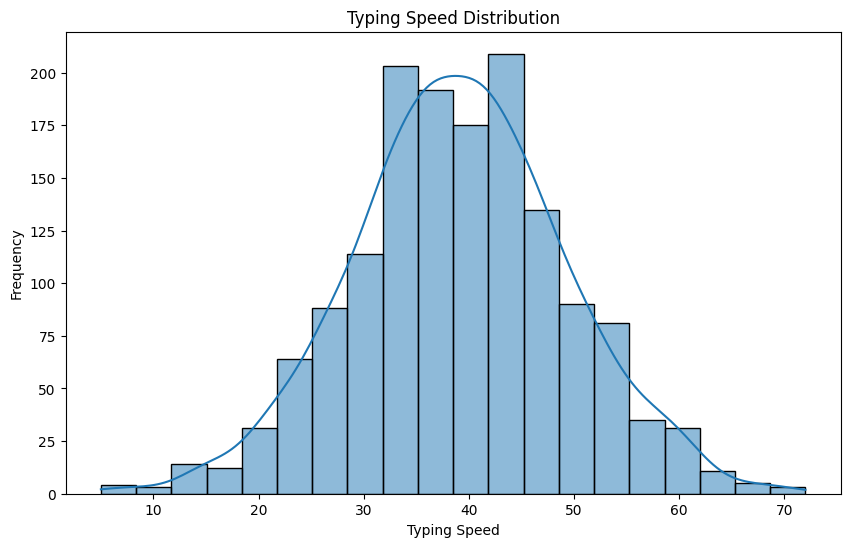

In [6]:
# Create Histogram Plot
plt.figure(figsize=(10, 6))
sns.histplot(data['typing_speed'], bins=20, kde=True)
plt.xlabel('Typing Speed')
plt.ylabel('Frequency')
plt.title('Typing Speed Distribution')
plt.show()

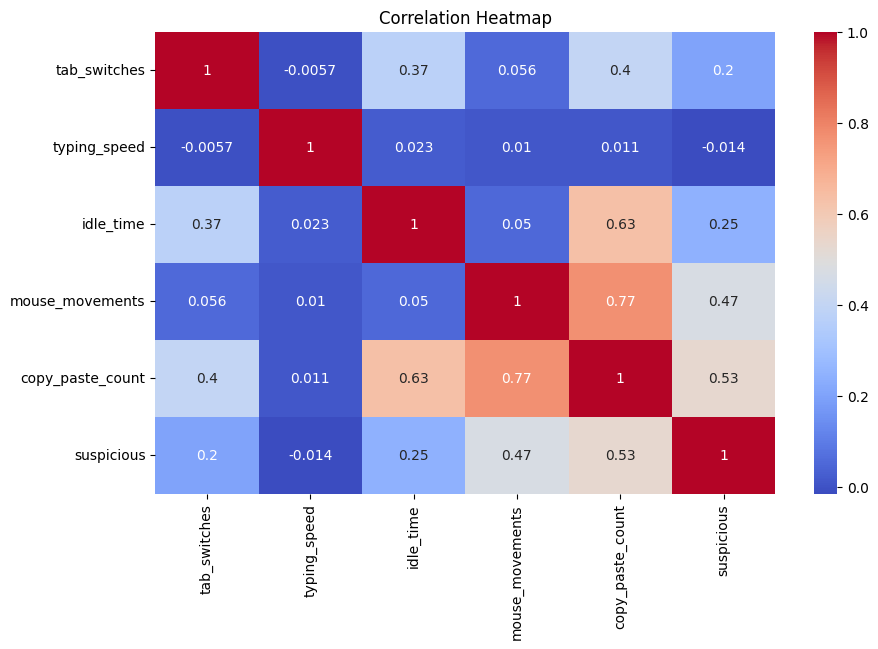

In [8]:
# Create Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Select Input Features

In [9]:
X = data.drop('suspicious', axis=1)
y = data['suspicious']

## Output labels
0 = Normal

1 = Suspicious

# Train Test Split

In [10]:
# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.65, random_state=42)

# Create Machine Learning Model

In [11]:
# Create Fandom Forest model
model = RandomForestClassifier(n_estimators = 100)
from sklearn.naive_bayes import GaussianNB
model2 = GaussianNB()


# Train Model

In [12]:
# Train model using training data
model.fit(X_train, y_train)

RandomForestClassifier()

# Make Predction

In [13]:
predictions = model.predict(X_test)

# Evaluate Model

In [14]:
# Calculate Accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy}")
# Print classification report
print(classification_report(y_test, predictions))

Accuracy: 0.8358974358974359
              precision    recall  f1-score   support

           0       0.84      0.83      0.84       492
           1       0.83      0.84      0.84       483

    accuracy                           0.84       975
   macro avg       0.84      0.84      0.84       975
weighted avg       0.84      0.84      0.84       975



# Save Training model

In [17]:
import joblib
# Save trained model
joblib.dump(model, 'cheating_model.pkl')
print('\nModel Saved Successfully')


Model Saved Successfully
